In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib import rcParams

In [9]:
import os
import subprocess
import shutil

def setup_ctex_path():
    """配置 CTEX 路径"""
    
    # CTEX 的安装路径
    ctex_paths = [
        r"C:\CTEX\MiKTeX\miktex\bin",
        r"C:\CTEX\MiKTeX\bin",
        r"C:\CTEX\CTeX\bin",
        r"C:\CTEX\bin"
    ]
    
    # 添加到系统 PATH
    for path in ctex_paths:
        if os.path.exists(path):
            os.environ['PATH'] = path + os.pathsep + os.environ['PATH']
            print(f"✅ 已添加 CTEX 路径: {path}")
            break
    else:
        print("❌ 未找到 CTEX 的 bin 目录，请手动检查路径")
        return False
    
    return True

def verify_ctex_installation():
    """验证 CTEX 安装"""
    
    print("🔍 验证 CTEX 安装...")
    
    # 检查 LaTeX 相关命令
    commands = ['pdflatex', 'latex', 'bibtex']
    
    for cmd in commands:
        path = shutil.which(cmd)
        if path:
            print(f"✅ 找到 {cmd}: {path}")
            
            # 测试版本
            try:
                result = subprocess.run([cmd, '--version'], 
                                      capture_output=True, text=True, timeout=5)
                print(f"   版本: {result.stdout.splitlines()[0] if result.stdout else 'Unknown'}")
            except:
                print(f"   版本: 可用但无法获取版本信息")
        else:
            print(f"❌ 未找到 {cmd}")
    
    return any(shutil.which(cmd) for cmd in commands)

# 配置并验证
if setup_ctex_path():
    verify_ctex_installation()

✅ 已添加 CTEX 路径: C:\CTEX\MiKTeX\miktex\bin
🔍 验证 CTEX 安装...
✅ 找到 pdflatex: C:\CTEX\MiKTeX\miktex\bin\pdflatex.EXE
   版本: MiKTeX-pdfTeX 2.9.4307 (1.40.12) (MiKTeX 2.9)
✅ 找到 latex: C:\CTEX\MiKTeX\miktex\bin\latex.EXE
   版本: MiKTeX-pdfTeX 2.9.4307 (1.40.12) (MiKTeX 2.9)
✅ 找到 bibtex: C:\CTEX\MiKTeX\miktex\bin\bibtex.EXE
   版本: MiKTeX-BibTeX 2.9.4360 (0.99d) (MiKTeX 2.9)


In [10]:
# 读取数据部分保持不变
N = 10000
a = 0.5
E_min = 0
E_max = 400
k = 10

#del duqu, duqu_array_1, duqu_array_2, duqu_array_3
duqu = []

for y1, y2 in zip([2,0,2], [0,2,2]):
    file_name = f"N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}正.xlsx"
    save_path = os.path.join(fr"D:\结果\一维PT对称系统\能带数据\N10000_y1{y1}_y2{y2}", file_name)
    loaded_df = pd.read_excel(save_path)
    duqu.append(loaded_df["E"])
    duqu.append(loaded_df["K"])


# 数据处理函数（添加降采样）
def process_array(base_array, downsample_n=1):
    # 确保是二维数组，形状为(2, N)
    arr = np.vstack(base_array)
    
    # 降采样：每downsample_n个点取一个
    if downsample_n > 1:
        arr = arr[:, ::downsample_n]
    
    # 创建新行
    new_row1 = arr[1] - 2*np.pi
    new_row2 = arr[1] * (-1)
    new_row3 = arr[1] * (-1) + 2*np.pi
    
    # 垂直堆叠所有行
    return np.vstack([arr, new_row1, new_row2, new_row3])

# 处理数据并降采样
n=10
duqu_array_1 = process_array(duqu[0:2], downsample_n=n)
duqu_array_2 = process_array(duqu[2:4], downsample_n=n)
duqu_array_3 = process_array(duqu[4:6], downsample_n=n)

# 检查降采样后的数据形状
print(f"降采样后的数据形状:")
print(f"duqu_array_1: {duqu_array_1.shape}")
print(f"duqu_array_2: {duqu_array_2.shape}")
print(f"duqu_array_3: {duqu_array_3.shape}")



降采样后的数据形状:
duqu_array_1: (5, 3180)
duqu_array_2: (5, 2905)
duqu_array_3: (5, 2909)


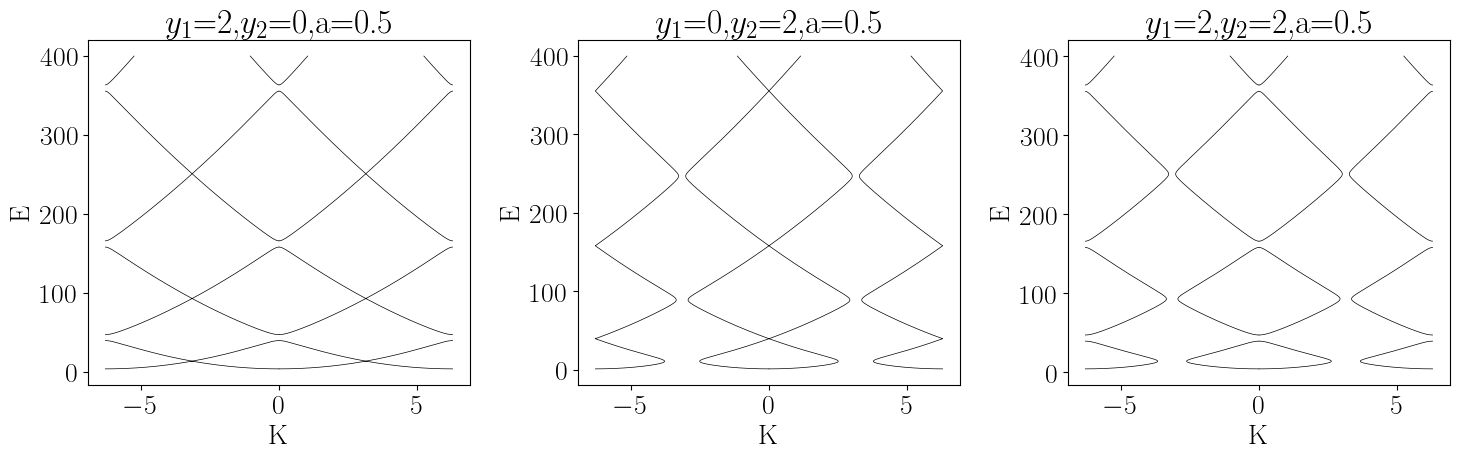

In [11]:
shidong = 1  # 控制是否保存图片

# 假设 duqu_array_1, duqu_array_2, duqu_array_3 已经是处理好的数据
quanbu = []
quanbu.append(duqu_array_1)
quanbu.append(duqu_array_2)
quanbu.append(duqu_array_3)

# 创建 1x3 的子图布局（水平排列）
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))  # 1行3列，调整图形大小

for i, ax , y1, y2 in zip([0, 1, 2], axes,[2,0,2],[0,2,2]):  # 遍历 3 个子图
    for j, k in zip([0, 0, 0, 0], [1, 2, 3, 4]):
        x = quanbu[i][k]
        y = quanbu[i][j]
        
        # 创建一个掩码，标记哪些点需要断开
        mask = np.abs(np.diff(y)) > 2
        split_indices = np.where(mask)[0] + 1

        # 分割数组
        x_segments = np.split(x, split_indices)
        y_segments = np.split(y, split_indices)
        # 绘制每个段
        for xs, ys in zip(x_segments, y_segments):
            if len(xs) > 1:  # 只有多于一个点才绘制
                ax.plot(xs, ys, color='black', linewidth=0.5, alpha=1)
    
    
    ax.set_xlabel("K")  # 交换后，x 轴是 K
    ax.set_ylabel("E")  # 交换后，y 轴是 E
    ax.set_title(f"$y_1$={y1},$y_2$={y2},a=0.5")  # 子图标题

# 自动调整子图间距
plt.tight_layout()

# 如果需要保存
if shidong == 1:
    save_folder = fr"D:\结果\一维PT对称系统\图片"
    image_name = "nengdai_1x3_10.png"
    save_path = os.path.join(save_folder, image_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


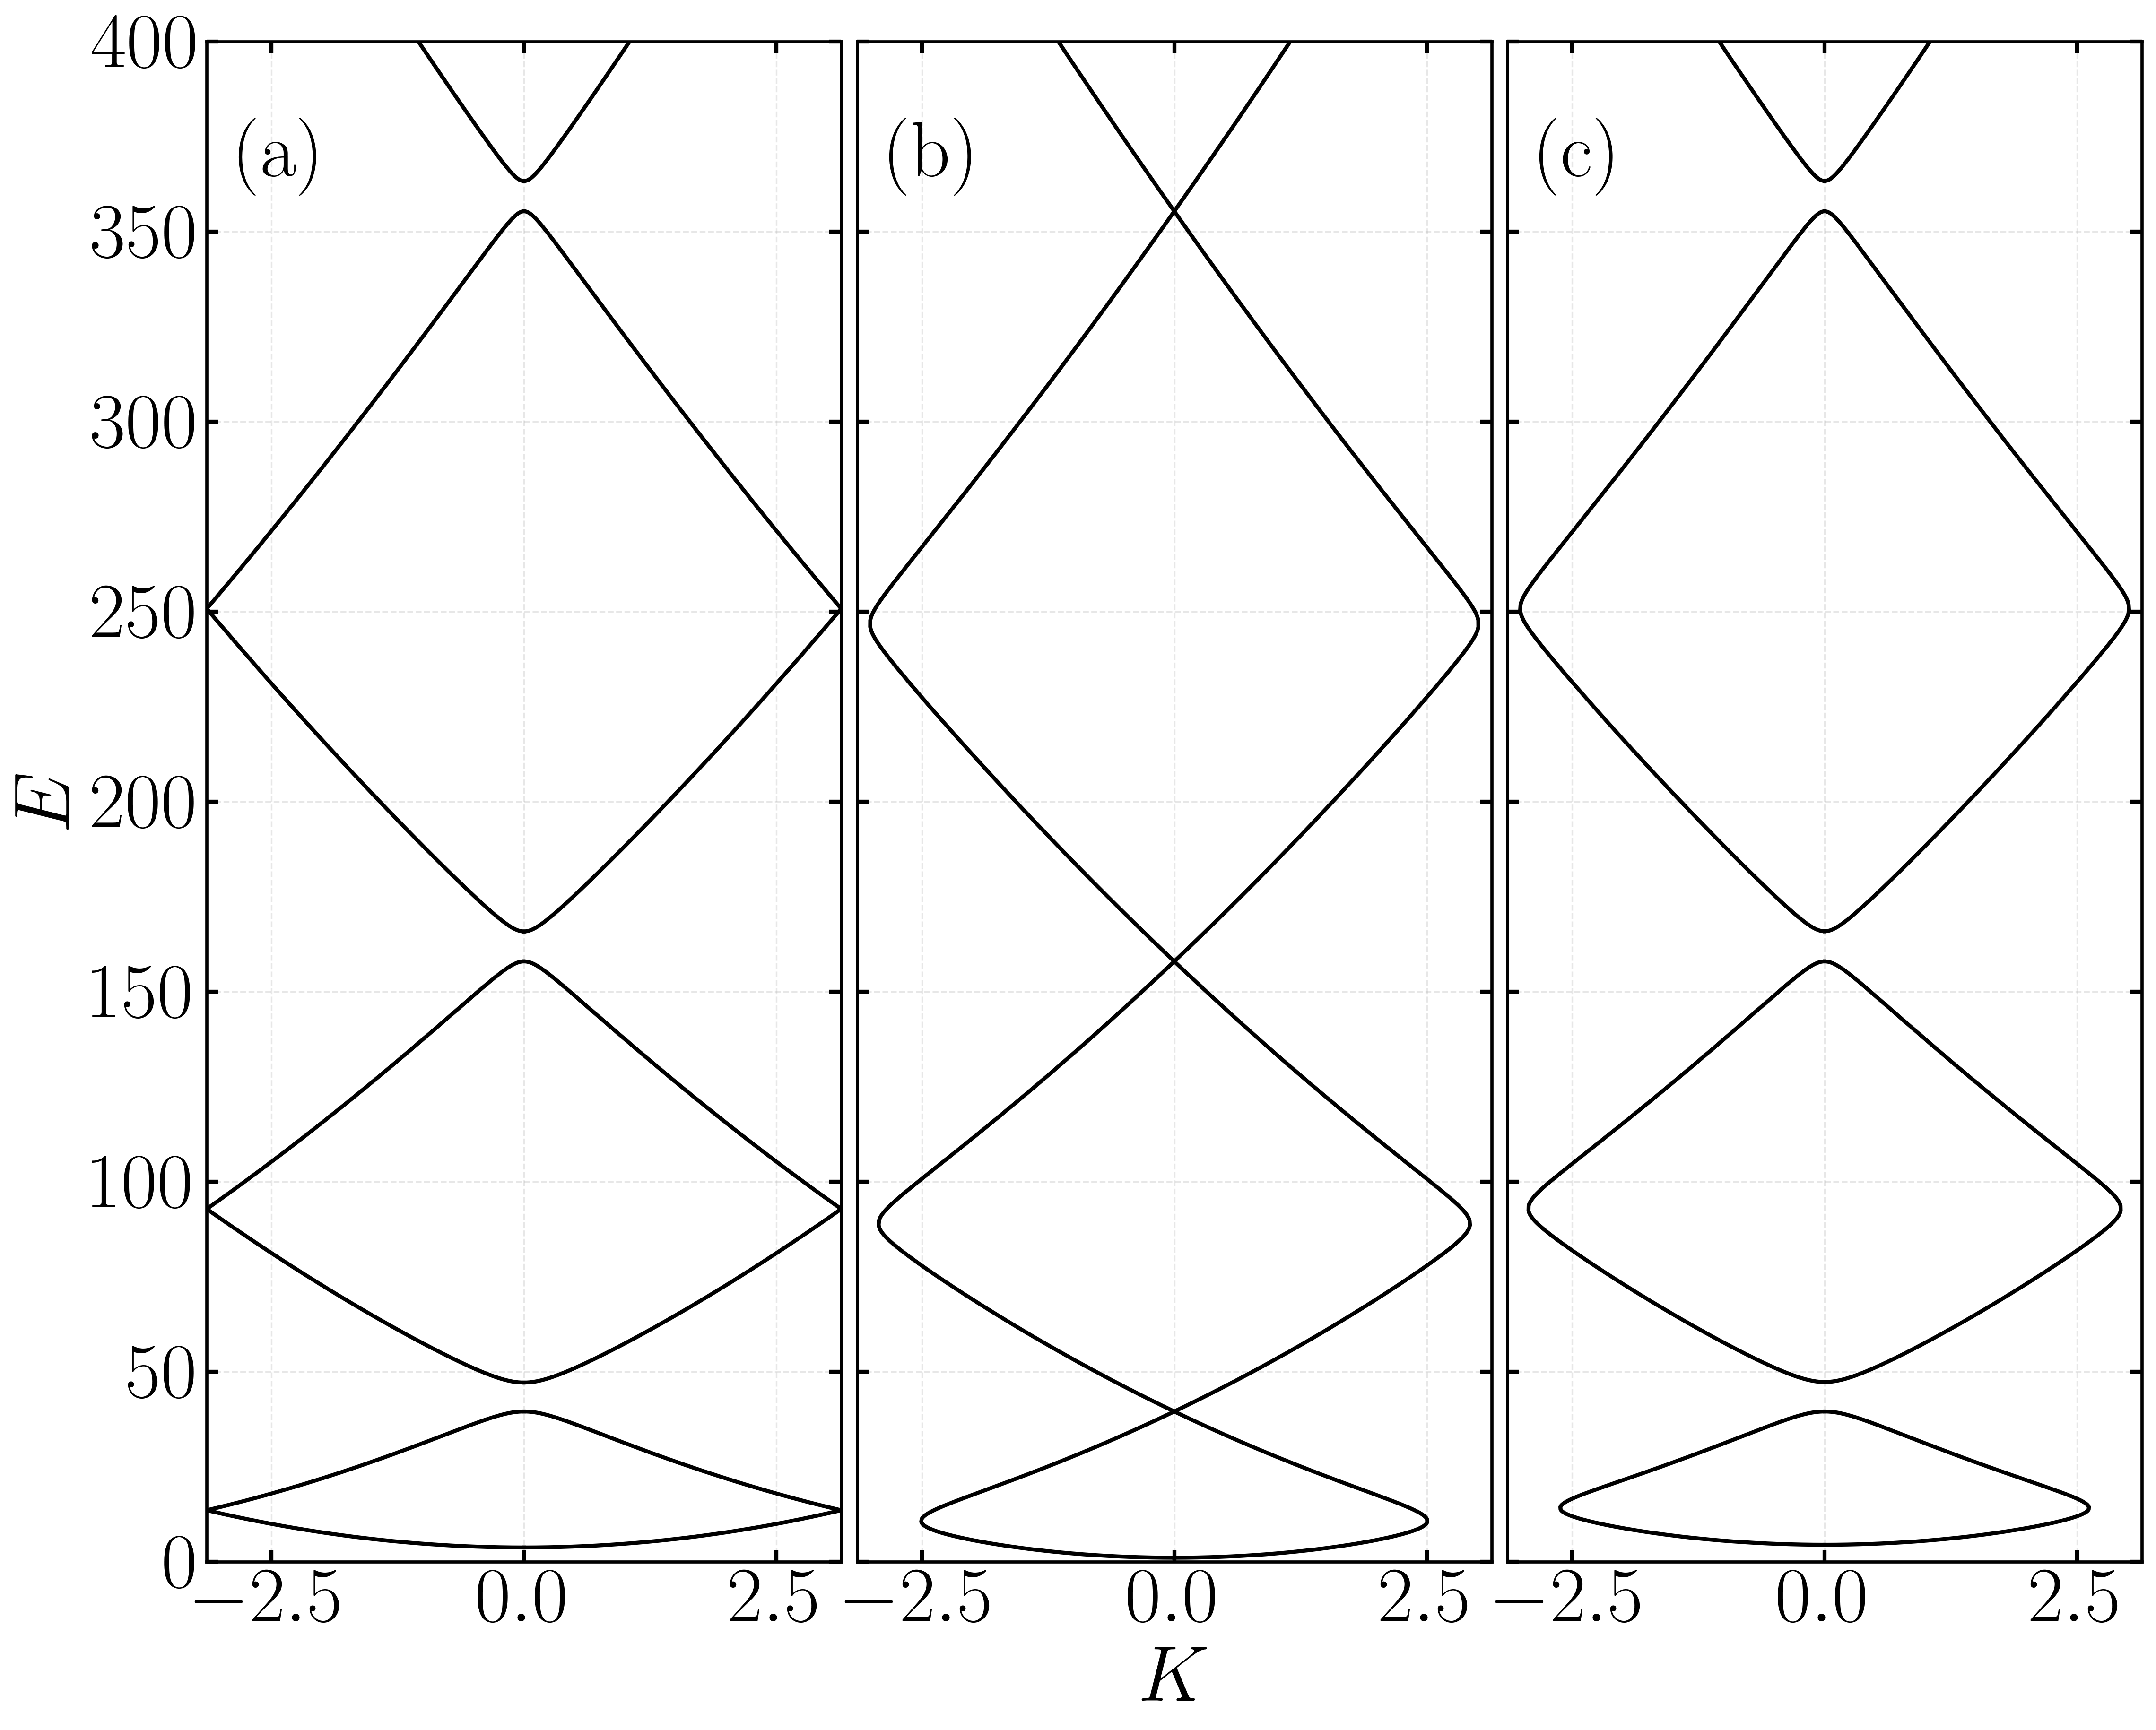

In [15]:
# 设置LaTeX字体（需要系统安装LaTeX）

plt.rcParams.update({
    "text.usetex": True,  # 使用LaTeX渲染文本
    "font.family": "serif",  # 使用衬线字体
    "font.serif": ["Times New Roman"],  # Times New Roman是物理文献常用字体
    "font.size": 20,  # 基础字号
})

shidong = 1  # 控制是否保存图片


# 创建 1x3 的子图布局（水平排列）
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 12), dpi=300)  # 调整图形大小和分辨率

# 设置统一的坐标轴范围（根据实际数据调整）
x_min, x_max = -1*np.pi, 1*np.pi
y_min, y_max = 0, 400

# 子图标签
subplot_labels = [r"$\mathrm{(a)}$", r"$\mathrm{(b)}$", r"$\mathrm{(c)}$"]

for i, ax, y1, y2, label in zip([0, 1, 2], axes, [2,0,2], [0,2,2], subplot_labels):
    for j, k in zip([0, 0, 0, 0], [1, 2, 3, 4]):
        x = quanbu[i][k]
        y = quanbu[i][j]
        
        # 创建一个掩码，标记哪些点需要断开
        mask = np.abs(np.diff(y)) > 2
        split_indices = np.where(mask)[0] + 1

        # 分割数组
        x_segments = np.split(x, split_indices)
        y_segments = np.split(y, split_indices)
        # 绘制每个段
        for xs, ys in zip(x_segments, y_segments):
            if len(xs) > 1:  # 只有多于一个点才绘制
                ax.plot(xs, ys, color='black', linewidth=2, alpha=1)
    # 设置坐标轴
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # 只在第一个子图显示x轴标签
    if i==0 or i==2:
        ax.set_xlabel(r"", fontsize=40)
    if i==1:
        ax.set_xlabel(r"$K$", fontsize=40)
    
    
    
    # 只在第一个子图显示y轴标签
    if i == 0:
        ax.set_ylabel(r"$E$", fontsize=40)
    else:
        ax.set_ylabel(r"", fontsize=30) # 仅去掉标签，保留刻度
    
    ax.text(0.05, 0.95, label, transform=ax.transAxes,
        fontsize=40, va='top', ha='left')


    
    # 美化刻度（保留所有刻度线）
    ax.tick_params(
    axis='both', which='major', direction='in',
    length=6, width=2, labelsize=40,
    top=True, right=True  # 开启上和右边的刻度线
)
    ax.tick_params(
    axis='both', which='minor', direction='in',
    length=3, width=2,
    top=True, right=True
)

# 去掉第二、第三个子图的y轴刻度数字
    if i != 0:
        ax.set_yticklabels([])
    # 添加网格
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # 设置边框线宽
    for spine in ax.spines.values():
        spine.set_linewidth(1.6)

# 调整子图间距（保持适当间距）
plt.tight_layout(pad=0.0, w_pad=-0.3, h_pad=0.0)  # 调整w_pad控制水平间距

# 保存为EPS格式（矢量图）
if shidong == 1:
    save_folder = fr"C:\Users\taoji\Desktop\论文写作\wenwu\yiweiPTduichen\wenben\一维PT对称系统"
    image_name = "nengdai.eps"
    save_path = os.path.join(save_folder, image_name)
    plt.savefig(save_path, format='eps', bbox_inches='tight', dpi=300)
    # PNG格式（适合预览或报告）
    png_path = os.path.join(save_folder, "image_base.png")
    plt.savefig(png_path, format='png', bbox_inches='tight', dpi=300)

plt.show()

In [50]:
# 读取 Excel 文件  透射
N = 100
n3 = 0
n4 = 0
y1 = 2
y2 = 2
a = 0.5  
file_name = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_E_change.xlsx"
save_dir = fr"D:\结果\一维PT对称系统\N_{N},y1_{y1},y2_{y2}"
save_path = os. path.join(save_dir, file_name)
loaded_df = pd.read_excel(save_path)

# 将字符串形式的列表转换为实际的列表
def safe_literal_eval(x):
    if isinstance(x, str):  # 如果是字符串才尝试解析
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return x
    else:  # 已经是数字或列表就直接返回
        return x

E_set = loaded_df["E_set"].apply(safe_literal_eval)
T_set = loaded_df["T_set"].apply(safe_literal_eval)
R_set = loaded_df["R_set"].apply(safe_literal_eval)
Sum_values_set = loaded_df["Sum_values"].apply(safe_literal_eval)

In [51]:
# 读取 Excel 文件  能带数据
N = 100
y1 = 2
y2 = 2
a = 0.5
E_min = 0
E_max = 400
k=10

file_name = f"能带数据N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}nk.xlsx"
save_path = os. path.join(fr"D:\结果\一维PT对称系统\N_{N},y1_{y1},y2_{y2}", file_name)
loaded_df = pd.read_excel(save_path)

gongzhen =loaded_df["E"]
#print("从 Excel 加载的字典（列表格式）:", energy_levels)
#type(gongzhen[2])

file_name = f"能带数据N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}_最大值处.xlsx"
save_path = os. path.join(fr"D:\结果\一维PT对称系统\N_{N},y1_{y1},y2_{y2}", file_name)
loaded_df_1 = pd.read_excel(save_path)

zuidashi =loaded_df_1["E"]


In [52]:
E_kaishi=154
E_jieshu=169
pushu_qi=int(400000*E_kaishi/400)
pushu_jie=int(400000*E_jieshu/400)
E_set_1=E_set[pushu_qi:pushu_jie]
T_set_1=T_set[pushu_qi:pushu_jie]
R_set_1=R_set[pushu_qi:pushu_jie]
Sum_values_set_1=Sum_values_set[pushu_qi:pushu_jie]

gongzhen_3=[num for num in gongzhen if E_kaishi <= num <= E_jieshu]
zuidashi_3=[num for num in zuidashi if E_kaishi <= num <= E_jieshu]

shidong=1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


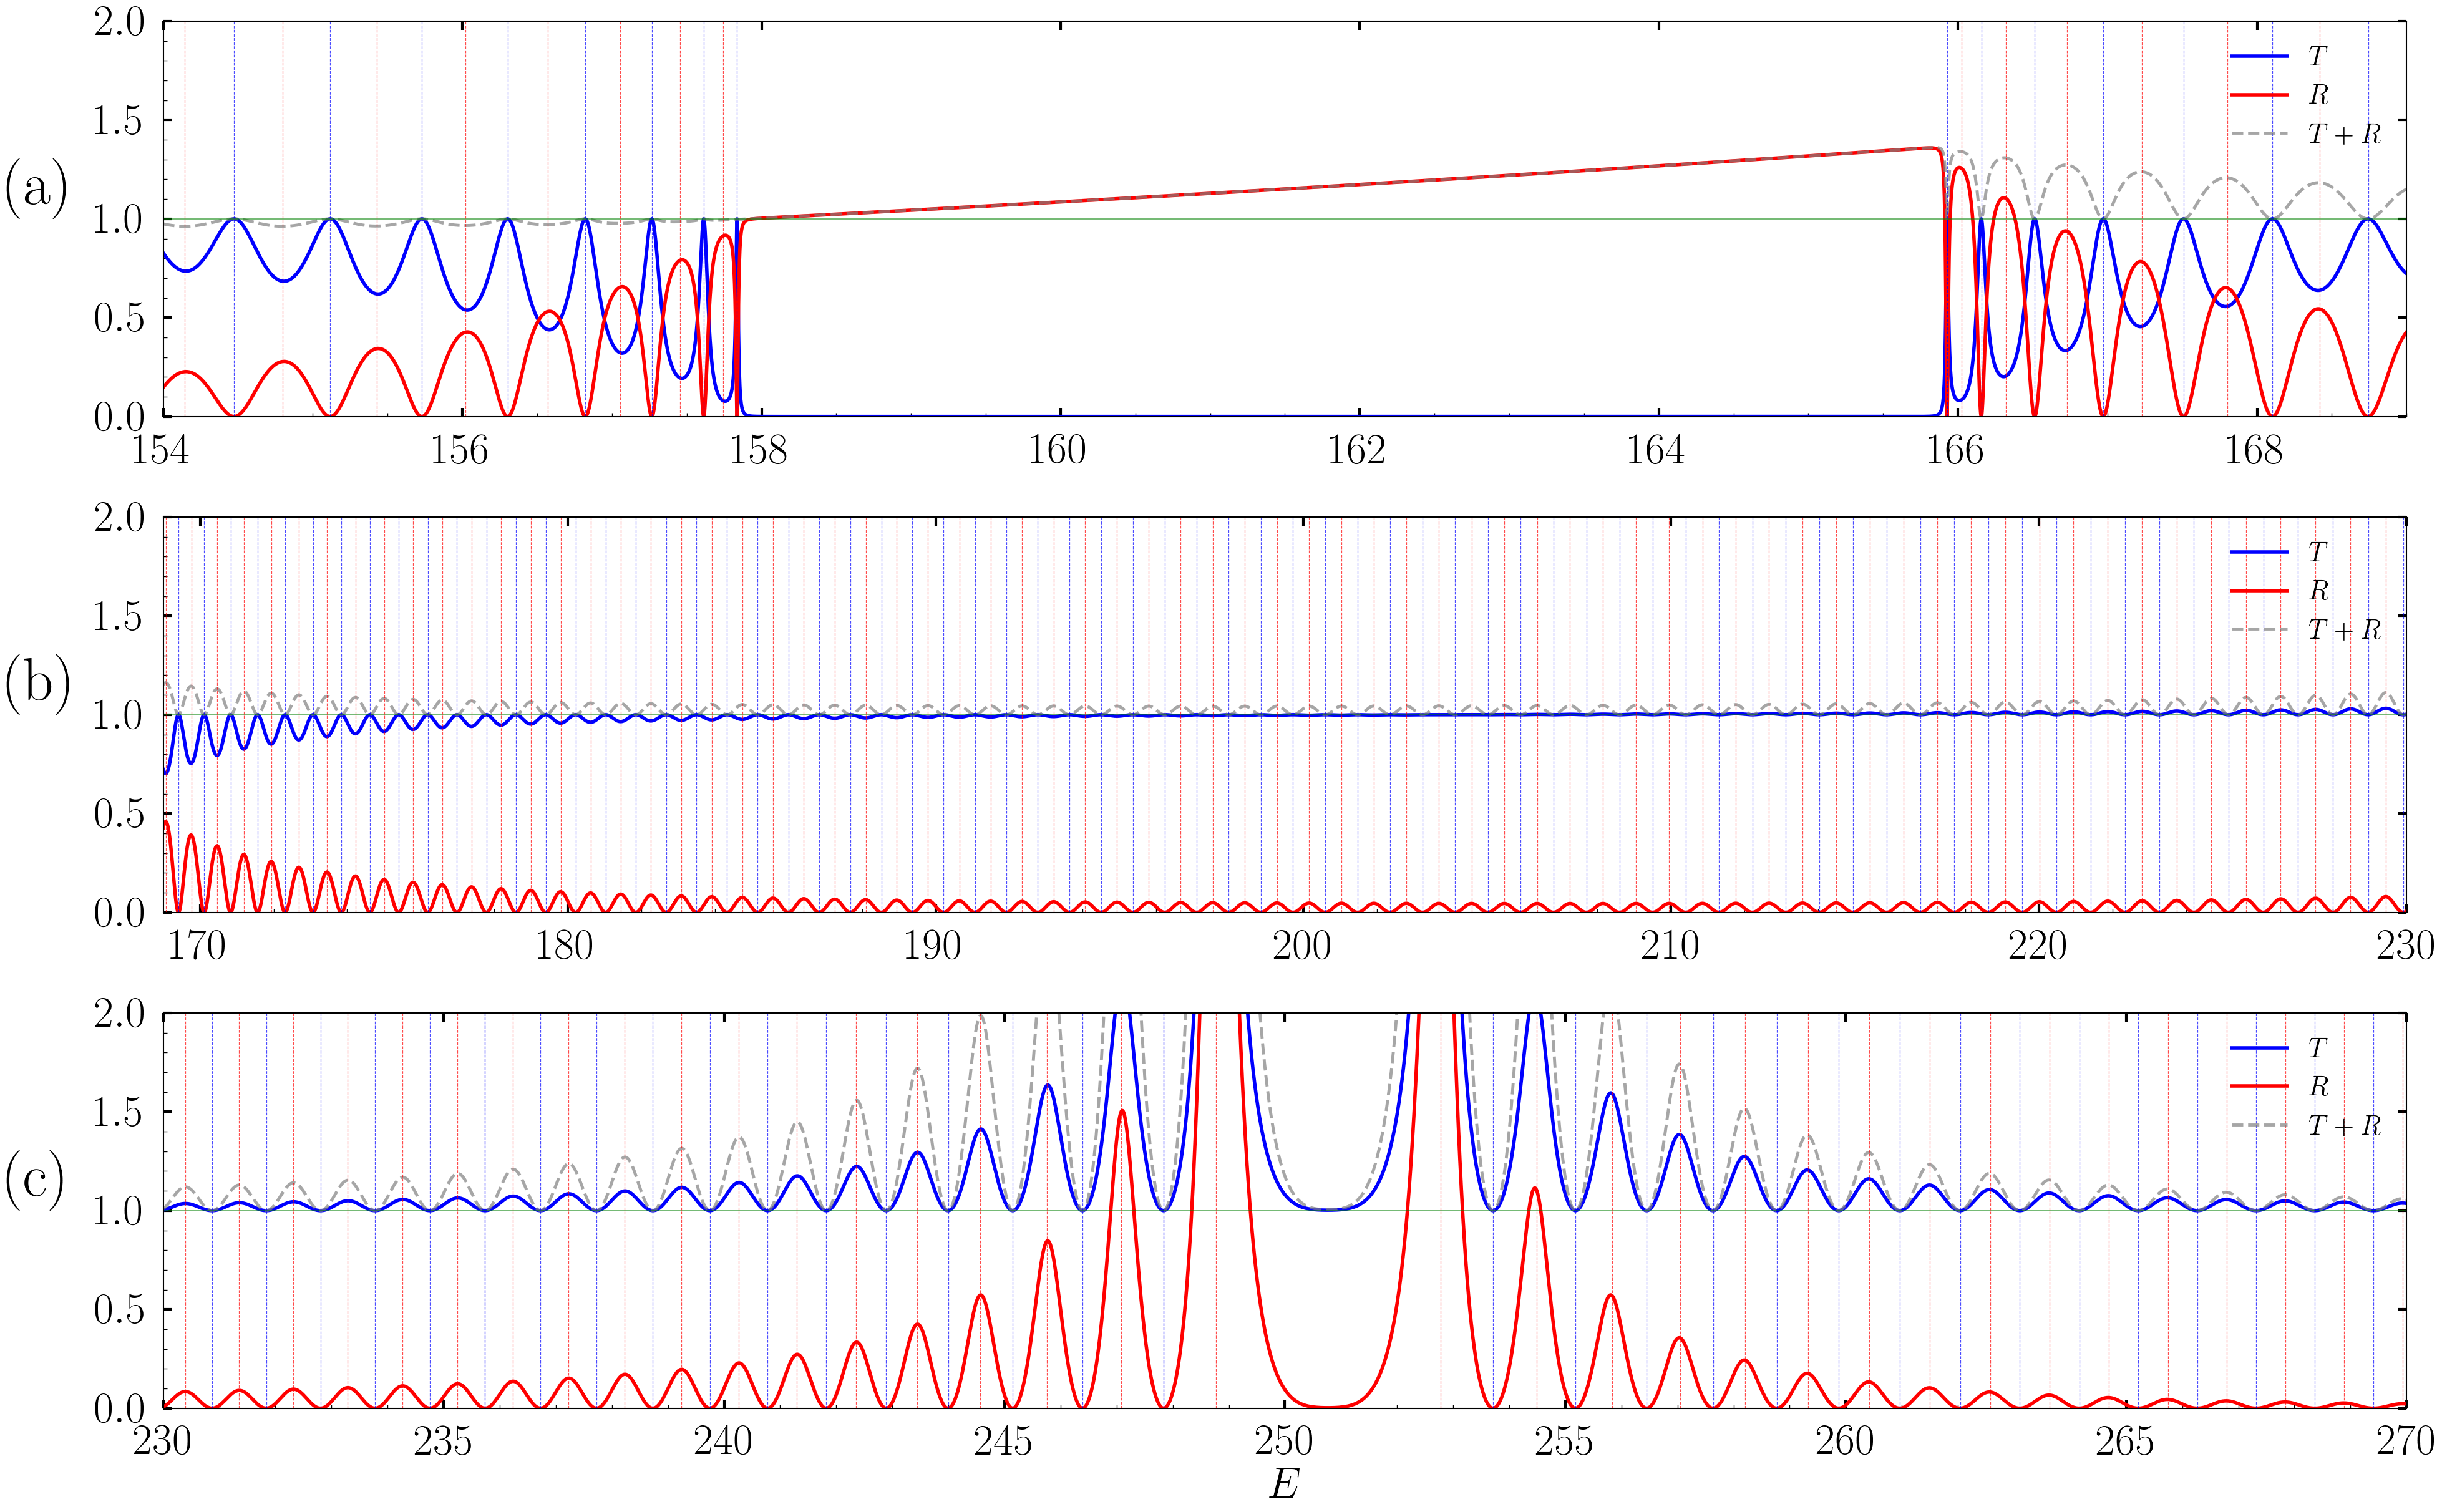

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import os
# 设置 Matplotlib 样式更接近物理文献
plt.rcParams.update({
    "font.family": "Times New Roman",     # 使用常见文献字体
    "font.size": 32,                      # 全局字体大小 16*2=32
    "axes.linewidth": 1.5,                # 坐标轴边框线宽
    "xtick.direction": "in",              # x轴刻度线向内
    "ytick.direction": "in",              # y轴刻度线向内
    "xtick.major.width": 1.2,             # x轴主刻度线宽
    "ytick.major.width": 1.2,             # y轴主刻度线宽
    "xtick.major.size": 6,                # x轴主刻度线长度
    "ytick.major.size": 6,                # y轴主刻度线长度
    "xtick.minor.width": 1.0,             # x轴次刻度线宽
    "ytick.minor.width": 1.0,             # y轴次刻度线宽
    "xtick.minor.size": 4,                # x轴次刻度线长度
    "ytick.minor.size": 4,                # y轴次刻度线长度
    "legend.frameon": False,              # 图例无边框
    "legend.fontsize": 64,                # 图例字体大小
    "axes.titlesize": 32,                 # 标题字体大小
    "axes.labelsize": 50,                 # 坐标轴标签字体大小
    "xtick.labelsize": 80,                # x轴刻度标签字体大小 10*2=20
    "ytick.labelsize": 80,                # y轴刻度标签字体大小 10*2=20
})

# 假设以下变量已定义（示例数据）
# E_set, T_set, R_set, Sum_values_set, gongzhen, zuidashi, N, n3, n4, y1, y2, a

# 定义3个子图的参数范围
ranges = [
    {'E_kaishi': 154, 'E_jieshu': 169},
    {'E_kaishi': 169, 'E_jieshu': 230},
    {'E_kaishi': 230, 'E_jieshu': 270}
]

# 创建3×1的子图布局
fig, axes = plt.subplots(3, 1, figsize=(40, 25))  # 3行1列，总高度调整

for i, ax in enumerate(axes):
    # 获取当前子图的参数范围
    current_range = ranges[i]
    E_kaishi = current_range['E_kaishi']
    E_jieshu = current_range['E_jieshu']
    
    # 计算数据范围
    pushu_qi = int(400000 * E_kaishi / 400)
    pushu_jie = int(400000 * E_jieshu / 400)
    E_set_1 = E_set[pushu_qi:pushu_jie]
    T_set_1 = T_set[pushu_qi:pushu_jie]
    R_set_1 = R_set[pushu_qi:pushu_jie]
    Sum_values_set_1 = Sum_values_set[pushu_qi:pushu_jie]
    
    # 筛选共振和最大值点
    gongzhen_3 = [num for num in gongzhen if E_kaishi <= num <= E_jieshu]
    zuidashi_3 = [num for num in zuidashi if E_kaishi <= num <= E_jieshu]
    
    # 绘制当前子图
    ax.plot(E_set_1, T_set_1, color='blue', linewidth=4,label=r'$T$')
    ax.plot(E_set_1, R_set_1, color='red', linewidth=4,label=r'$R$')
    ax.plot(E_set_1, Sum_values_set_1, 
            color='gray', linestyle='--', 
            linewidth=3.5, alpha=0.7,
            label=r'$T + R$')
    
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in')

    # 添加子图编号 (a), (b), (c)
    ax.text(-0.07, 0.50, rf"$\mathrm{{({chr(97+i)})}}$", transform=ax.transAxes,
        fontsize=70, va='bottom', ha='left',   # 25*2=50
        fontweight='bold')

    
    # 设置坐标轴和辅助线
    ax.set_xlim(E_kaishi, E_jieshu)
    ax.set_ylim(0, 2)
    ax.axhline(y=1, color='green', linestyle='-', linewidth=1.1, alpha=0.7)
    for gongzhenzhi in gongzhen_3:
        ax.axvline(x=gongzhenzhi, color='blue', linestyle='--', linewidth=0.9, alpha=0.7)
    for zuidashi_1 in zuidashi_3:
        ax.axvline(x=zuidashi_1, color='red', linestyle='--', linewidth=0.9, alpha=0.7)
    
    # 只在最下方子图显示xlabel，所有子图显示ylabel
    if i == 2:
        ax.set_xlabel(r'$E$')
    #ax.set_ylabel('Value')

# 只调整y轴刻度标签位置
    ax.tick_params(
    axis='y', which='major', direction='in',
    length=10, width=3, labelsize=50,
    top=True, right=True,
    pad=20  # y轴标签向左移动
)

    ax.tick_params(
    axis='x', which='major', direction='in',
    length=10, width=3, labelsize=50,
    top=True, right=True,
    pad=20    # x轴标签向下移动（如果需要的话）
)
    # 修改图例位置为右上角
    ax.legend(loc='upper right', fontsize=32)  # 设置图例字体大小
# 调整子图间距
plt.tight_layout(pad=0.1, w_pad=1.0, h_pad=-50)

plt.tight_layout()

# 保存图像（PNG 和 EPS 两种格式）
if shidong == 1:
    save_folder = r"C:\Users\taoji\Desktop\论文写作\wenwu\yiweiPTduichen\wenben\11"
    os.makedirs(save_folder, exist_ok=True)
    
    base_name = f"fig02"
    
    png_path = os.path.join(save_folder, base_name + ".png")
    eps_path = os.path.join(save_folder, base_name + ".eps")
    
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    plt.savefig(eps_path, format='eps', dpi=300, bbox_inches='tight')  # 添加此行


plt.show()

In [76]:
# 读取 Excel 文件  能带数据

file_name = f"0第三能带极点处的透射率数据.xlsx"
save_path = os. path.join(fr"D:\结果", file_name)
loaded_df = pd.read_excel(save_path)

N_set =loaded_df["N_set"]
T_set =loaded_df["T_set"]



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


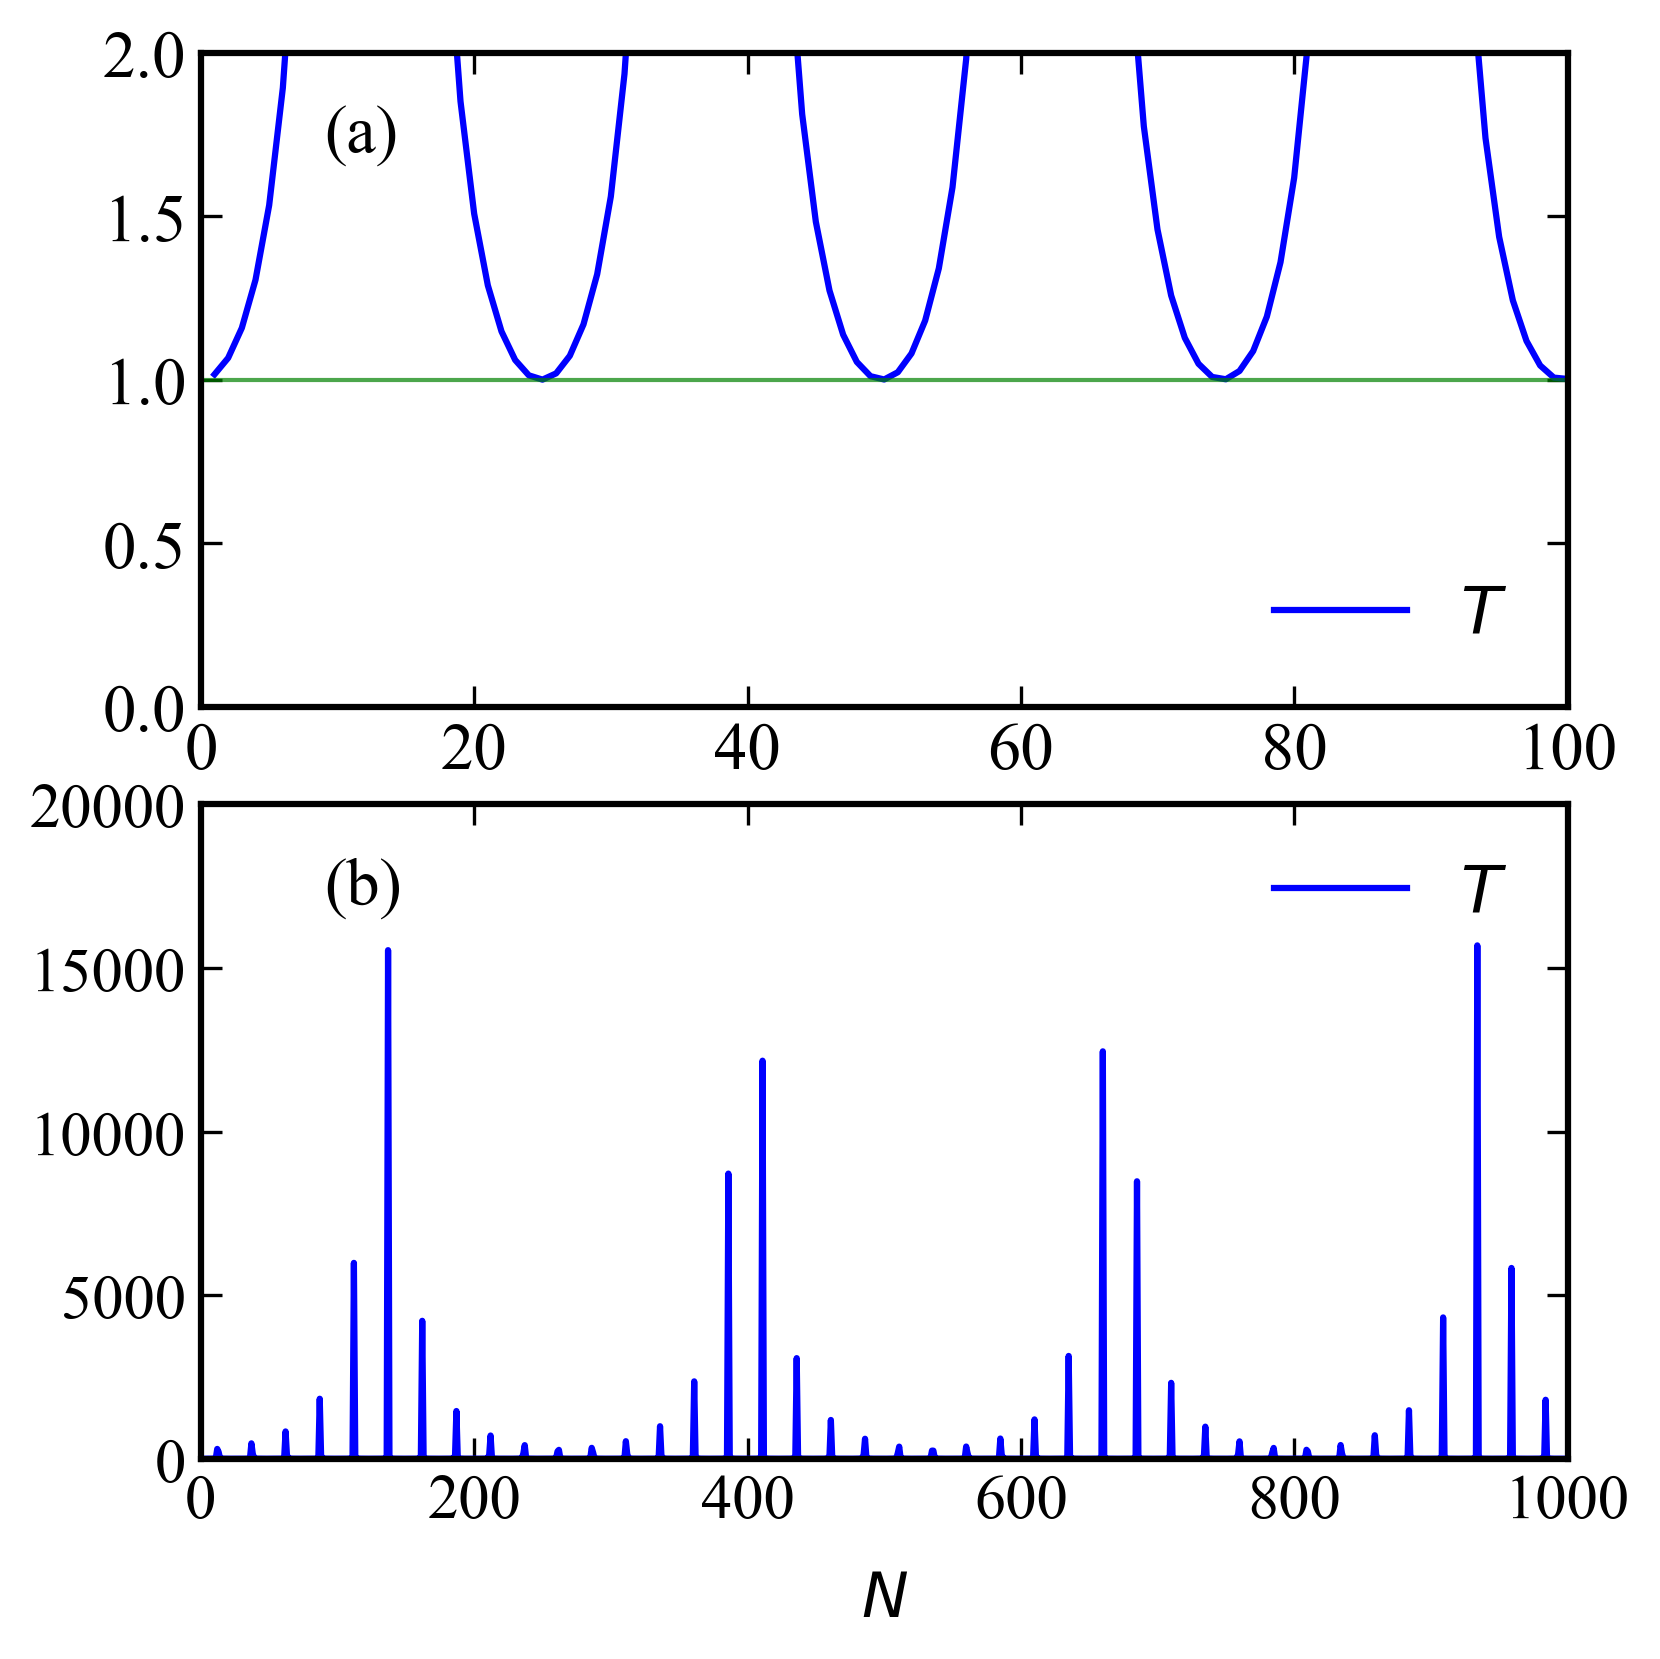

In [115]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 设置LaTeX字体（期刊风格）
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "ps.useafm": True,  # 确保EPS输出质量
    "pdf.use14corefonts": True,
})

# 创建2×1子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), dpi=300, sharex=False)

# 子图(a) - 放大视图
ax1.plot(N_set, T_set, color='blue', label=r'$T$')
ax1.set_ylim(0, 2)
ax1.set_xlim(0, 100)
ax1.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
ax1.set_ylabel('', labelpad=10)
ax1.legend(loc='lower right', frameon=False,fontsize=16)  # 改为右下角

# 添加子图标签(a)
ax1.text(0.09, 0.92, '(a)', transform=ax1.transAxes, 
         fontsize=16, fontweight='normal', va='top', ha='left')
ax1.tick_params(
    axis='both', which='major', direction='in',
    length=5, width=0.8, labelsize=16,
    top=True, right=True  # 开启上和右边的刻度线
    )
# 子图(b) - 完整视图
ax2.plot(N_set, T_set, color='blue', label=r'$T$')
ax2.set_ylim(0, 20000)
ax2.set_xlim(0, 1000)
ax2.set_xlabel(r'$N$', labelpad=10,fontsize=15)
ax2.set_ylabel('', labelpad=10)
ax2.legend(loc='upper right', frameon=False,fontsize=16)  # 改为右下角

# 添加子图标签(b)
ax2.text(0.09, 0.92, '(b)', transform=ax2.transAxes,
         fontsize=16, fontweight='normal', va='top', ha='left')

ax2.tick_params(
    axis='both', which='major', direction='in',
    length=5, width=0.8, labelsize=15,
    top=True, right=True  # 开启上和右边的刻度线
    )

# 调整子图间距
plt.tight_layout(pad=2.0, h_pad=0.0)

# 保存图片
save_folder = r"C:\Users\taoji\Desktop\论文写作\wenwu\yiweiPTduichen\wenben\11"

# 保存为EPS格式
eps_name = "fig04_jidianchu.eps"
eps_path = os.path.join(save_folder, eps_name)
plt.savefig(eps_path, format='eps', bbox_inches='tight', dpi=300)


plt.show()

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import ast
h1 = 1
m = 0.5
def coupling(matrix_1, matrix_2):
    s11_1, s12_1 = matrix_1[0, 0], matrix_1[0, 1]
    s21_1, s22_1 = matrix_1[1, 0], matrix_1[1, 1]
    s11_2, s12_2 = matrix_2[0, 0], matrix_2[0, 1]
    s21_2, s22_2 = matrix_2[1, 0], matrix_2[1, 1]
    
    denom = 1 - s11_2 * s22_1
    s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
    s12 = s12_1 * s12_2 / denom
    s21 = s21_2 * s21_1 / denom
    s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom
    
    return np.array([[s11, s12], [s21, s22]], dtype=np.complex128)

def multiple_coupling(matrix_collect):
    result = matrix_collect[0]
    for matrix in matrix_collect[1:]:
        result = coupling(result, matrix)
    return result

def coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a):
    constant_1 = 2 * m * (y1 + 1j * y2) / (h1**2)
    constant_2 = 2 * m * (y1 - 1j * y2) / (h1**2)
    
    di = np.array([constant_1 if i % 2 == 0 or i >= 2 * N and i < 2 * N + n3 else constant_2 
                   for i in range(2 * N + n3 + n4)], dtype=complex)
    
    x_0 = 0
    x_1 = a * (2 * N + n3 + n4) - a + x_0
    location = np.linspace(x_0, x_1, 2 * N + n3 + n4)
 #   print(location)
    k = np.sqrt(E * 2 * m) / h1
    exp_2jk = np.exp(2j * k * location)
    exp_minus_2jk = np.exp(-2j * k * location)
    
    matrix_collect = np.zeros((2 * N + n3 + n4, 2, 2), dtype=complex)
    for i in range(2 * N + n3 + n4):
        s11 = di[i] * exp_2jk[i]
        s12 = 2j * k
        s21 = 2j * k
        s22 = di[i] * exp_minus_2jk[i]
        
        matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
  #  print(matrix_collect)
    return multiple_coupling(matrix_collect)

def Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[1, 0])**2)

def Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[0, 0])**2)

In [79]:
#测试
# 参数设置
N = 1
n3 = 0
n4 = 0
y1 = 2
y2 = 2
dianshu=1000
E=5
a_set__1 = np.linspace(0,3,dianshu)            
#a = 0.5                    #######np.linspace(0, 20, 10000)

# 计算数据
T_set__1 = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set__1]
R_set__1 = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set__1]
Sum_values__1 = [T + R   for T, R in zip(T_set__1, R_set__1)]

y2 = -2
# 计算数据
T_set__2 = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set__1]
R_set__2 = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set__1]
Sum_values__2 = [T + R   for T, R in zip(T_set__2, R_set__2)]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


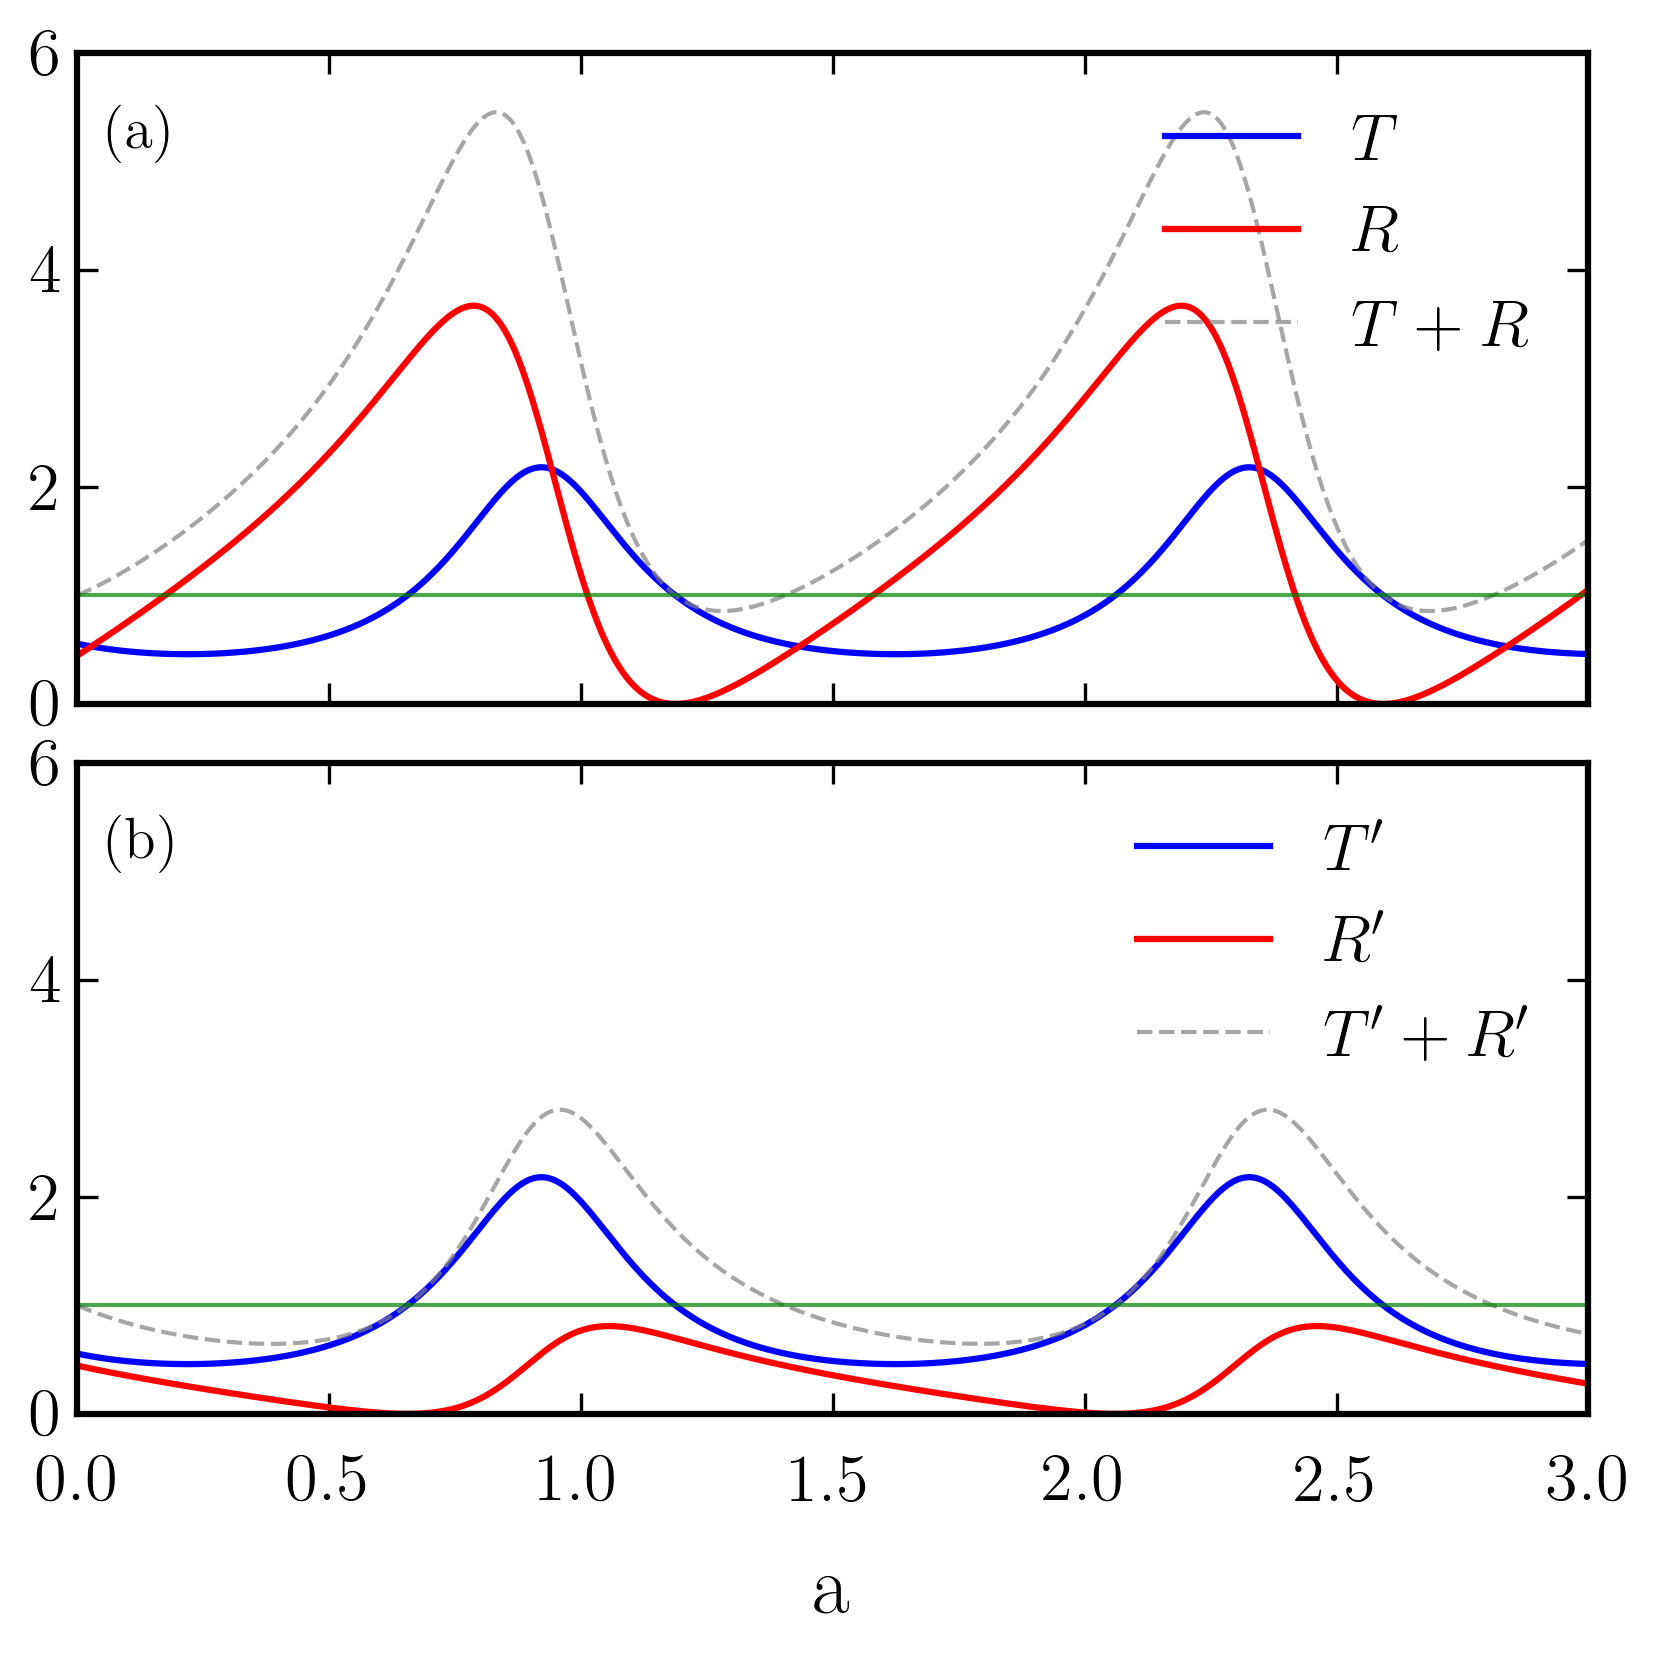

In [117]:
# 设置LaTeX字体（期刊风格）
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "ps.useafm": True,  # 确保EPS输出质量
    "pdf.use14corefonts": True,
})

# 创建2×1子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), dpi=300, sharex=False)

# 子图(a) - 放大视图
ax1.plot(a_set__1, T_set__1, color='blue', label=r'$T$')
ax1.plot(a_set__1, R_set__1, color='red', label=r'$R$')
ax1.plot(a_set__1, Sum_values__1, 
         color='gray', linestyle='--', 
         linewidth=1, alpha=0.7,
         label=r'$T+R$')
ax1.set_ylim(0, 6)
ax1.set_xlim(0, 3)
ax1.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
ax1.set_ylabel('', labelpad=10)
ax1.legend(loc='upper right', frameon=False, fontsize=16)  # 改为右下角

# 添加子图标签(a)
ax1.text(0.02, 0.92, '(a)', transform=ax1.transAxes, 
         fontsize=14, fontweight='normal', va='top', ha='left')
ax1.tick_params(
    axis='both', which='major', direction='in',
    length=5, width=0.8, labelsize=16,
    top=True, right=True, 
     # 开启上和右边的刻度线
    )
ax1.set_xticklabels([])

# 子图(b) - 完整视图
ax2.plot(a_set__1, T_set__2, color='blue', label=r'$T^{\prime}$')
ax2.plot(a_set__1, R_set__2, color='red', label=r'$R^{\prime}$')
ax2.plot(a_set__1, Sum_values__2, 
         color='gray', linestyle='--', 
         linewidth=1, alpha=0.7,
         label=r'$T^{\prime}+R^{\prime}$')
ax2.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
ax2.set_ylim(0, 6)
ax2.set_xlim(0, 3)
ax2.set_xlabel('a', labelpad=10,fontsize=20)
ax2.set_ylabel('', labelpad=10)
ax2.legend(loc='upper right', frameon=False, fontsize=16)  # 改为右下角


# 添加子图标签(b)
ax2.text(0.02, 0.92, '(b)', transform=ax2.transAxes,
         fontsize=14, fontweight='normal', va='top', ha='left')
# 只调整x轴刻度标签位置（向下移动）
ax2.tick_params(
    axis='x', which='major', direction='in',
    length=5, width=0.8, labelsize=16,
    top=True, right=True,
    pad=10  # x轴标签向下移动
)

# y轴保持默认位置
ax2.tick_params(
    axis='y', which='major', direction='in',
    length=5, width=0.8, labelsize=16,
    top=True, right=True
    # 不设置pad，让y轴标签保持默认位置
)
# 调整子图间距
plt.tight_layout(pad=2.0, h_pad=0.0)

# 保存图片
save_folder = r"C:\Users\taoji\Desktop\论文写作\wenwu\yiweiPTduichen\wenben\11"

# 保存为EPS格式
eps_name = "fig03_zhengfanshe.eps"
eps_path = os.path.join(save_folder, eps_name)
plt.savefig(eps_path, format='eps', bbox_inches='tight', dpi=300)

# 保存为PNG格式
#png_name = "zhengfanshe.png"
#png_path = os.path.join(save_folder, png_name)
#plt.savefig(png_path, format='png', bbox_inches='tight', dpi=300)

plt.show()